In [2]:
pip install yfinance scikit-learn pandas matplotlib

   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.7 MB ? eta -:--:--
   ------------------------- -------------- 1.0/1.7 MB 2.0 MB/s eta 0:00:01
   ---------------------------------------- 1.7/1.7 MB 2.8 MB/s eta 0:00:00
  Attempting uninstall: cffi
    Found existing installation: cffi 1.17.1
    Uninstalling cffi-1.17.1:
      Successfully uninstalled cffi-1.17.1
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Importing Libraries

In [1]:
import pandas as pd #imported required libraries
import yfinance as yf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

## Downloading stock data

In [2]:
stock = yf.download('AAPL', start='2020-01-01', end='2025-01-01') #We use Apple's stock (AAPL) as an example. Data includes Open, High, Low, Close, and Volume.
print(stock.head()) #to display first five rows of dataset

[*********************100%***********************]  1 of 1 completed

Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2020-01-02  72.333862  72.394070  71.091169  71.344039  135480400
2020-01-03  71.630638  72.389257  71.406666  71.563205  146322800
2020-01-06  72.201408  72.239942  70.503546  70.754014  118387200
2020-01-07  71.861855  72.466338  71.642697  72.211056  108872000
2020-01-08  73.017830  73.318870  71.565614  71.565614  132079200


## Prepare data using open, high, low, and volume as inputs to predict the next day's close price.

In [12]:
stock['Next_Close'] = stock['Close'].shift(-1) # Create the target variable (Next Day Closing Price)
stock = stock.dropna() # shift(-1) moves the Close column one row up so that each row

X = stock[['Open', 'High', 'Low', 'Volume']] # contains the closing price of the following trading day.
y = stock['Next_Close']

## Split data

In [7]:
X_train, X_test, y_train, y_test = train_test_split( # Split the dataset into training and testing sets
    X, y, test_size=0.2, random_state=42 # 80% of the data is used for training the model and 20% is reserved for testing and evaluating its performance
)

## Train Linear regression model

In [8]:
model = LinearRegression() # A Linear Regression model is initialized.
#The model attempts to find a linear relationship between stock features and the next day's closing price.

model.fit(X_train, y_train) #The fit() function trains the model using the training dataset.

LinearRegression()

## Make predictions

In [9]:
y_pred = model.predict(X_test) # Use the trained model to predict the next day's closing price for the data in the test set.
# The predicted values are stored in y_pred.

## Plot Actual vs Predicted Prices

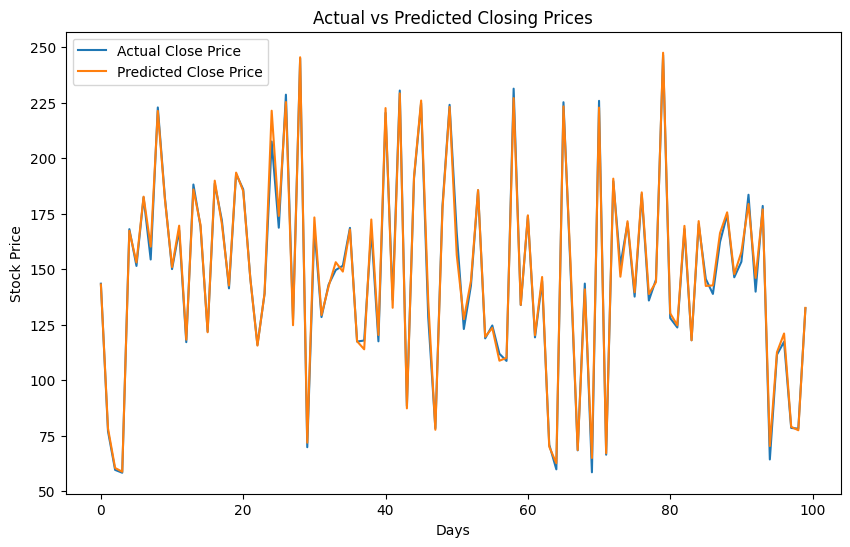

In [10]:
plt.figure(figsize=(10,6))

plt.plot(y_test.values[:100], label='Actual Close Price') # Plot the actual closing prices from the test dataset and display only the first 100 values for better visualization
plt.plot(y_pred[:100], label='Predicted Close Price') 

plt.title('Actual vs Predicted Closing Prices')
plt.xlabel('Days')
plt.ylabel('Stock Price')
plt.legend() #Display the legend to distinguish between actual and predicted prices

plt.show()